# Ex. D2: Scheduling Problems

Scheduling problems are an important class of problems in Operations Research. They consist of distributing the execution of a set of tasks over time, subject to various constraints--sequence of tasks, due dates, limited resource availability--with the objective to optimize a criterion, such as the total duration, the number of tasks that finish late, etc. 

These problems may come from many different fields: project management, industrial production, telecommunications, information systems, transport, timetabling. With the exception of the well-known case of (empirical) project scheduling, these problems are difficult to solve to optimality if they grow large. Nevertheless, instances of reasonable size (such as those encountered in the CCDS) have become solvable by LP, thanks to the power of recent software. See the CPLEX Benchmark example.

The examples considered here will cover:

- empirical project scheduling;
- single-machine scheduling, usually for a critical, bottle-neck machine.

Other flavors, not considered here, are:

- flow-shop scheduling with production lines, where all products/jobs are run through in the same order;
- job shop scheduling, where every product/job has a different processing order.

The methods covered here, are:

- empirical distribution approaches,
- optimal approaches (MILP),
- Big-M method,
- disjunctive programming.

Together, these will provide all the basic building-blocks needed for the CCDS examples and use-cases.

## Background Material 

- for basics of LP and MILP see the introductory `pyomo` tutorials above;
- for advanced cases with uncertainty see below.

## Project Scheduling

Given a set of tasks and their durations, we seek the earliest completion time, or any function of it. There is a _precedence_ graph for the tasks.

One variant consists of earning a bonus for every week the work finishes early. But this requires additional expenses (manpower, equipment). When should the project be completed to maximize profit?

In general, resources will be limited - please see the Resource Constrained Project Scheduling Problem [RCPSP]() below.

## Single-Machine Job Sequencing

In workshops it frequently happens that a single machine determines the throughput of the entire production---for example, a machine of which only one is available, the slowest machine in a production line, etc. This machine is called the *critical machine* or the *bottleneck.* In such a case it is important to schedule the tasks that need to be performed by this machine in the best possible way.

The aim of the problem is to provide a simple model for scheduling operations on a single machine and that may be used with different objective functions. We shall see here how to minimize: 
- the total processing time,
- the average processing time, and
- the total tardiness.

We are given the following elements.
- A set of tasks (or jobs) is to be processed on a single machine.
- The execution of tasks is non-preemptive (i.e. an operation may not be interrupted before its completion).
- For every task $i$ its release date and duration are given.
- For the last optimization criterion (total tardiness), a due date (latest completion time) is also required to measure the tardiness, that is, the amount of time by which the completion of jobs exceeds their respective due dates.

What is the optimal value for each of the objectives: minimizing the total duration of the schedule (makespan), the mean processing time or the total tardiness?

In this example, we will compare:
- empirical scheduling methods,
- optimized scheduling using disjunctions.

---

### Model Formulation

Given a set $\mathcal{J} = \{ J_1, J_2, \ldots, J_n \}$ of $n$ jobs, and the start/release time $s_j,$ the duration $d_j$ and the due date $t_j,$ for each job $j=1,\ldots,n,$ find a schedule that satisfies a given criterion. These criteria will either be empirical rules, or optimal objectives. 

We begin by loading the necessry modules and checking the vailability of the chosen solver.

In [1]:
solver = "appsi_highs"
import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)
assert SOLVER.available(), f"Solver {solver} is not available."

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

### Job data

The data is given as a Pandas dataframe in which each row corresponds to a job, its release time, its duration, and its due date. This data could also be read from a suitable `json` input file.

### Objective

The problem is to sequence the jobs on the machine to meet the due dates, or show that no such sequence is possible.

In [3]:
jobs = pd.DataFrame(
    {
        "A": {"release": 2, "duration": 5, "due": 10},
        "B": {"release": 5, "duration": 6, "due": 21},
        "C": {"release": 4, "duration": 8, "due": 15},
        "D": {"release": 0, "duration": 4, "due": 10},
        "E": {"release": 0, "duration": 2, "due": 5},
        "F": {"release": 8, "duration": 3, "due": 15},
        "G": {"release": 9, "duration": 2, "due": 22},
    }
).T
display(jobs)

,release,duration,due
A,2,5,10
B,5,6,21
C,4,8,15
D,0,4,10
E,0,2,5
F,8,3,15
G,9,2,22


### Schedule data

A schedule is also represented here by a Pandas dataframe indexed by job names. The columns indicate the start, finish, and the amount by each job is past due. 

The following function creates the simplest schedule, corresponding to the scenario in which jobs are executed in the (lexical) order given by the `jobs` dataframe.

In [4]:
def schedule_jobs(jobs, seq):
    schedule = pd.DataFrame(index=jobs.index)
    t = 0
    for job in seq:
        t = max(t, jobs.loc[job]["release"])
        schedule.loc[job, "start"] = t
        t += jobs.loc[job, "duration"]
        schedule.loc[job, "finish"] = t
        schedule.loc[job, "past"] = max(0, t - jobs.loc[job, "due"])
    return schedule

schedule = schedule_jobs(jobs, jobs.index)
schedule

,start,finish,past
A,2.0,7.0,0.0
B,7.0,13.0,0.0
C,13.0,21.0,6.0
D,21.0,25.0,15.0
E,25.0,27.0,22.0
F,27.0,30.0,15.0
G,30.0,32.0,10.0


In [5]:
sum(schedule.loc[:, "past"]) # total lateness/tardiness

68.0

### Gantt chart

A classical way of visualizing scheduling data is a Gantt chart. The next cell defines a function `gantt` that plots a Gantt chart given JOBS and SCHEDULE information. 

The function also computes and prints the total past due, or lateness/tardiness.

Two charts are presented: one showing the job schedule and the other showing the  machine schedule. If no explicit `machine` information is contained in SCHEDULE, then it is assumed to be a single machine operation.

In [6]:
def gantt(jobs, schedule, title="", pastdue='TRUE'):
    w = 0.25  # bar width
    plt.rcParams.update({"font.size": 13})
    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(13, 2*0.7 * len(jobs.index)),
                           tight_layout=True)
    # Jobs plot
    for k, job in enumerate(jobs.index):
        r = jobs.loc[job, "release"]
        d = jobs.loc[job, "due"]
        s = schedule.loc[job, "start"]
        f = schedule.loc[job, "finish"]
        # Show job release-due window
        axs[0].fill_between(
            [r, d], [-k - w, -k - w], [-k + w, -k + w], lw=1, color="k", alpha=0.2
        )
        axs[0].plot(
            [r, r, d, d, r], [-k - w, -k + w, -k + w, -k - w, -k - w], lw=0.5, color="k"
        )
        # Show job start-finish window
        color = "g" if f <= d else "r"
        axs[0].fill_between(
            [s, f], [-k - w, -k - w], [-k + w, -k + w], color=color, alpha=0.6
        )
        axs[0].text(
            (s + f) / 2.0,
            -k,
            "Job " + job,
            color="white",
            weight="bold",
            ha="center",
            va="center",
        )
        # If past due
        if pastdue=='TRUE':
            if f > d:
                axs[0].plot([d] * 2, [-k + w, -k + 2 * w], lw=0.5, color="k")
                axs[0].plot([f] * 2, [-k + w, -k + 2 * w], lw=0.5, color="k")
                axs[0].plot([d, f], [-k + 1.5 * w] * 2, solid_capstyle="butt", lw=1, color="k")
                axs[0].text(
                    f + 0.5,
                    -k + 1.5 * w,
                    f"{schedule.loc[job, 'past']:.1f} past due",
                    va="center",
                )

    if pastdue=='TRUE':
        total_past_due = schedule["past"].sum()
    axs[0].set_ylim(-len(jobs.index), 1)
    if pastdue=='TRUE': 
        print(f'\nUsing the "{title}" strategy, the total past due is {total_past_due:.1f}\n')
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Jobs")
    axs[0].set_yticks([0,-1,-2,-3,-4,-5,-6],['A','B','C','D','E','F','G'])
    #axs[0].set_yticks(range(len(jobs)), jobs.index[::-1])
    axs[0].spines["right"].set_visible(False)
    #axs[0].spines["left"].set_visible(False)
    axs[0].spines["top"].set_visible(False)

    custom_lines = [
        Line2D([0], [0], c="k", lw=10, alpha=0.2),
        Line2D([0], [0], c="g", lw=10, alpha=0.6),
        Line2D([0], [0], c="r", lw=10, alpha=0.6),
    ]
    axs[0].legend(
        custom_lines,
        ["Job release/due window", "Completed on time", "Completed past due"],
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )
    axs[0].set_title('Job Schedule')

    # Machines plot
    SCHEDULE = schedule.T.to_dict()
    for j in SCHEDULE.keys():
        if 'machine' not in SCHEDULE[j].keys():
                SCHEDULE[j]['machine'] = 1
    MACHINES = sorted(set([SCHEDULE[j]['machine'] for j in SCHEDULE.keys()]))
    for j in sorted(SCHEDULE.keys()):
        idx = MACHINES.index(SCHEDULE[j]['machine'])
        x = SCHEDULE[j]['start']
        y = SCHEDULE[j]['finish']
        axs[1].fill_between([x,y],[idx-w,idx-w],[idx+w,idx+w], color='blue', alpha=0.5)
        axs[1].plot([x,y,y,x,x], [idx-w,idx-w,idx+w,idx+w,idx-w],lw=0.5, color='k')
        axs[1].text((SCHEDULE[j]['start'] + SCHEDULE[j]['finish'])/2.0,idx,
            'Job ' + j, color='white', weight='bold',
            horizontalalignment='center', verticalalignment='center')
    xlim = axs[0].get_xlim()
    axs[1].set_xlim(xlim)
    axs[1].set_ylim(-0.5, len(MACHINES)-0.5)
    axs[1].set_yticks(range(len(MACHINES)), MACHINES)

    
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Machines")
    axs[1].spines["right"].set_visible(False)
    #axs[1].spines["left"].set_visible(False)
    axs[1].spines["top"].set_visible(False)
    axs[1].set_aspect(3)
    axs[1].set_title('Machine Schedule', pad=30)


Using the "job order" strategy, the total past due is 68.0



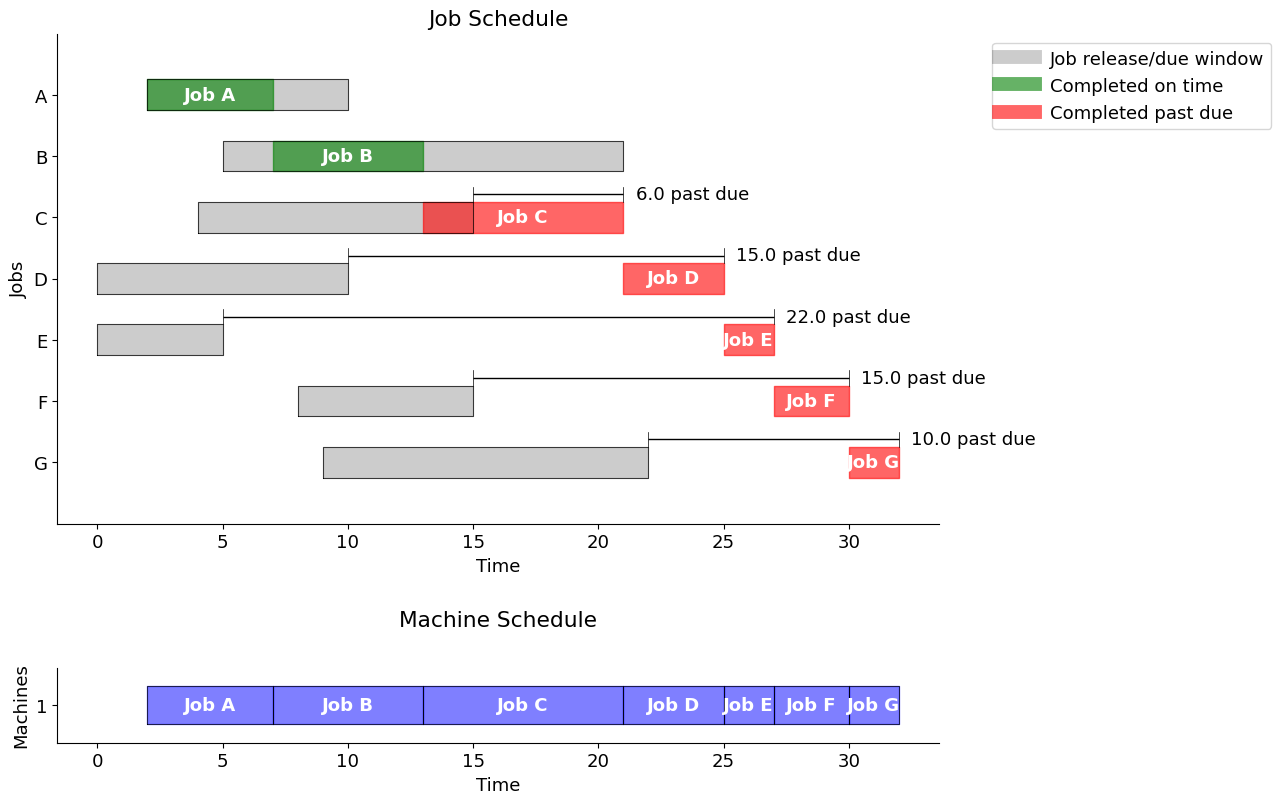

In [7]:
gantt(jobs, schedule, "job order")

### Key performance indicators

As presented above, a given schedule may not meet all of the due time requirements. In fact, a schedule meeting all of the requirements might not even be possible. So given a schedule, it is useful to have a function that computes key performance indicators.

In [8]:
def kpi(JOBS, SCHEDULE):
    KPI = {}
    KPI['Makespan'] = max(SCHEDULE[job]['finish'] for job in SCHEDULE)
    KPI['Max Pastdue'] = max(max(0, SCHEDULE[job]['finish'] - JOBS[job]['due']) for job in SCHEDULE)
    KPI['Sum of Pastdue'] = sum(max(0, SCHEDULE[job]['finish'] - JOBS[job]['due']) for job in SCHEDULE)
    KPI['Number Pastdue'] = sum(SCHEDULE[job]['finish'] > JOBS[job]['due'] for job in SCHEDULE)
    KPI['Number on Time'] = sum(SCHEDULE[job]['finish'] <= JOBS[job]['due'] for job in SCHEDULE)
    KPI['Fraction on Time'] = KPI['Number on Time']/len(SCHEDULE)
    return KPI

KPI_out = kpi(jobs.T.to_dict(), schedule.T.to_dict())
print("\n KPI for Job Order strategy \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'))


 KPI for Job Order strategy 

                          0
Makespan          32.000000
Max Pastdue       22.000000
Sum of Pastdue    68.000000
Number Pastdue     5.000000
Number on Time     2.000000
Fraction on Time   0.285714


## Empirical Scheduling Rules

To provide a comparison to scheduling using an optimal MILP model, we first implement three well-known and accepted empirical rules for scheduling jobs on a single machine:

* First in, first out (FIFO)
* Earliest due data (EDD)
* Shortest processing time (SPT)

In cases where there are many jobs, or where allocation must be quasi-immediate, these approaches are commonly employed.

### First-in, first-out (FIFO)

One of the most common scheduling rules is to execute jobs in the order they are released for processing, in other words "first-in, first-out" (FIFO). The following cell creates a Pandas dataframe that is indexed by job names and with  start time, finish time, and, if past due, the amount by which the job is past due.

The output sequence is determined by a sort of the values by release time, or first available time ("first-in").

Note the decrease in tardiness, from 68 to 31.


Using the "First in, First out" strategy, the total past due is 31.0



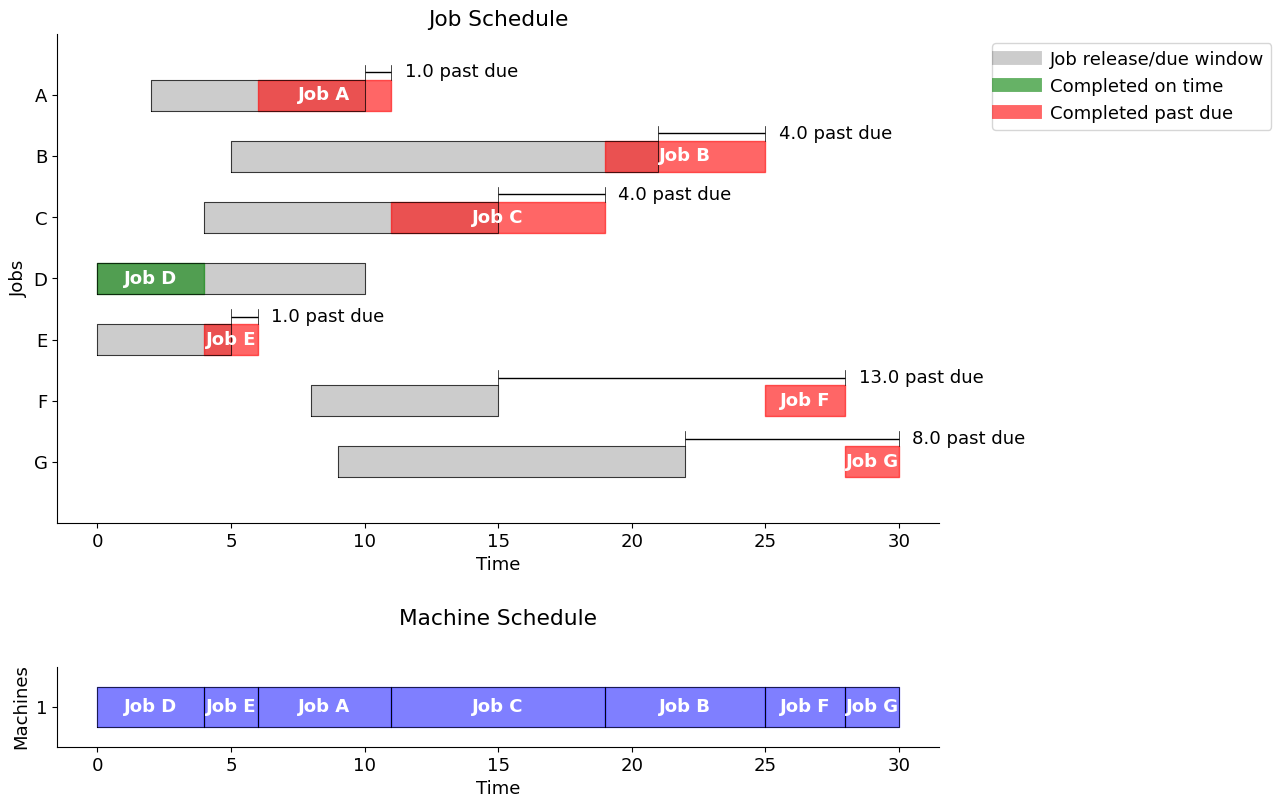

In [9]:
fifo = schedule_jobs(jobs, jobs.sort_values(by="release").index)
gantt(jobs, fifo, "First in, First out")

In [10]:
# print sorted schedule
sorted_fifo = fifo.sort_values(by='start')
display(sorted_fifo)

,start,finish,past
D,0.0,4.0,0.0
E,4.0,6.0,1.0
A,6.0,11.0,1.0
C,11.0,19.0,4.0
B,19.0,25.0,4.0
F,25.0,28.0,13.0
G,28.0,30.0,8.0


In [11]:
# print KPI's
KPI_out = kpi(jobs.T.to_dict(), fifo.T.to_dict())
print("\n KPI for First In, First Out strategy \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'))


 KPI for First In, First Out strategy 

                          0
Makespan          30.000000
Max Pastdue       13.000000
Sum of Pastdue    31.000000
Number Pastdue     6.000000
Number on Time     1.000000
Fraction on Time   0.142857


### Earliest due date (EDD)

When due dates are known, a common scheduling rule is to prioritize jobs by due date. This strategy will be familiar to any student deciding which homework assignment should be worked on next...

Note the further decrease of lateness to 27.


Using the "Earliest due date" strategy, the total past due is 27.0



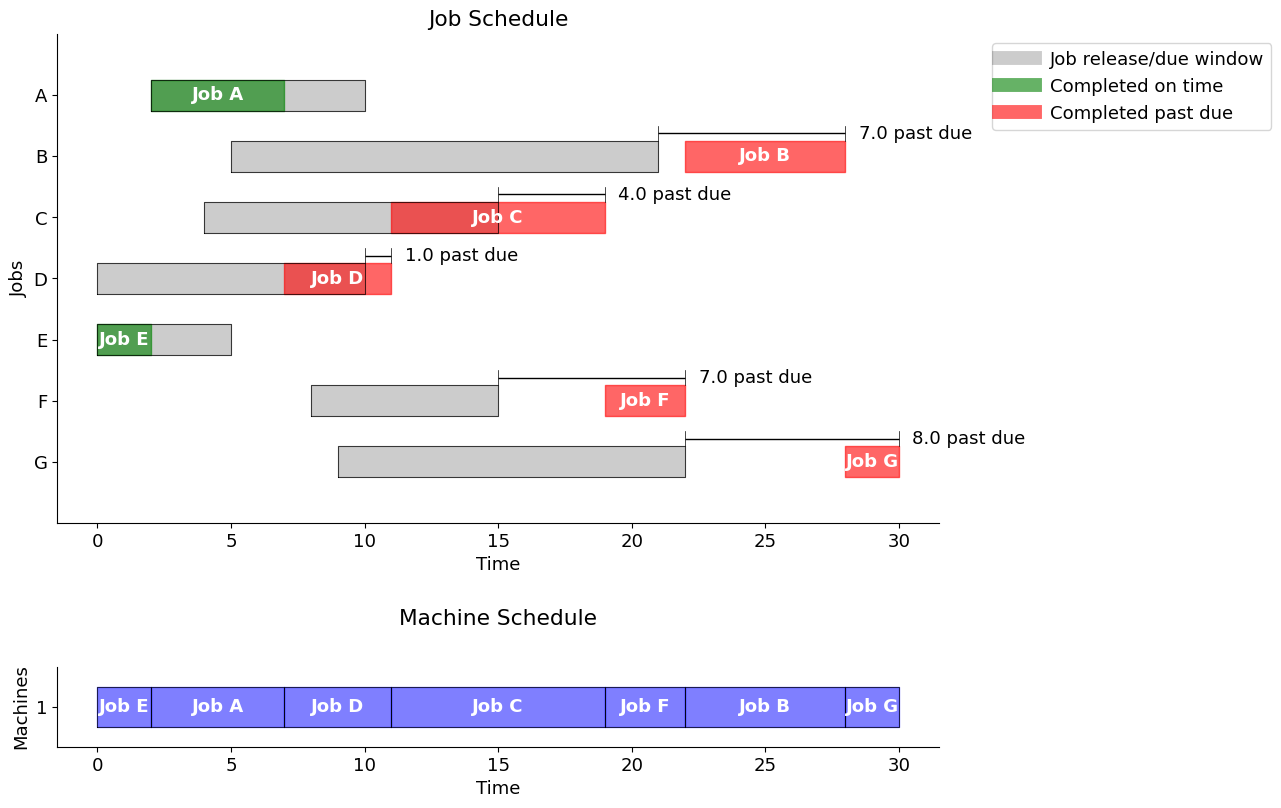

In [12]:
edd = schedule_jobs(jobs, jobs.sort_values(by="due").index)
gantt(jobs, edd, "Earliest due date")

In [13]:
# print sorted schedule
sorted_edd = edd.sort_values(by='start')
display(sorted_edd)

,start,finish,past
E,0.0,2.0,0.0
A,2.0,7.0,0.0
D,7.0,11.0,1.0
C,11.0,19.0,4.0
F,19.0,22.0,7.0
B,22.0,28.0,7.0
G,28.0,30.0,8.0


In [14]:
# print KPI's
KPI_out = kpi(jobs.T.to_dict(), edd.T.to_dict())
print("\n KPI for Earliest Due Date strategy \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'))


 KPI for Earliest Due Date strategy 

                          0
Makespan          30.000000
Max Pastdue        8.000000
Sum of Pastdue    27.000000
Number Pastdue     5.000000
Number on Time     2.000000
Fraction on Time   0.285714


**Observations**

Note that for EDD, we have two "ties" since the due dates are equal for A and D (10), and for C and F (15). In principle, we should compute the schedule for all the combinations (A before D, D before A, C before F, F before C) and choose the one with the smallest Past Due. In this case, it turns out that scheduling D before A, and F before C (i.e. reverse lexical order), we obtain a better schedule with Sum of Past Due = 23 only, Number of Past Due = 4, and Number on Time = 3. This gives a fraction of 0.43 on time.

### Shortest processing time (SPT)

When the job durations are known, another common scheduling rule is to prioritize jobs by their (remaining) processing time.

Note the increase in lateness to 51, due to idle time in the schedule.


Using the "Shortest Processing Time" strategy, the total past due is 51.0



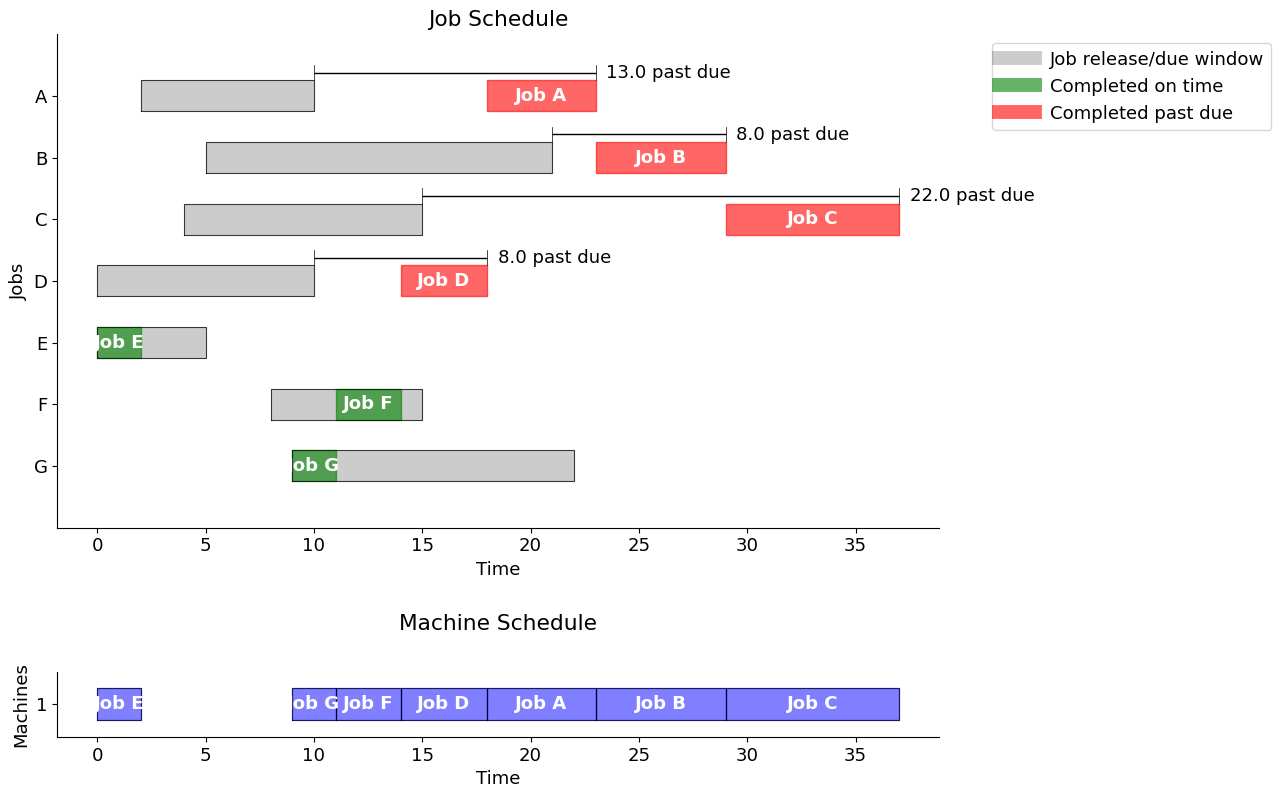

In [15]:
spt = schedule_jobs(jobs, jobs.sort_values(by="duration").index)
gantt(jobs, spt, "Shortest Processing Time")

In [16]:
# print sorted schedule
sorted_spt = spt.sort_values(by='start')
display(sorted_spt)

,start,finish,past
E,0.0,2.0,0.0
G,9.0,11.0,0.0
F,11.0,14.0,0.0
D,14.0,18.0,8.0
A,18.0,23.0,13.0
B,23.0,29.0,8.0
C,29.0,37.0,22.0


In [17]:
# print KPI's
KPI_out = kpi(jobs.T.to_dict(), spt.T.to_dict())
print("\n KPI for Shortest Processing Time strategy \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'))


 KPI for Shortest Processing Time strategy 

                          0
Makespan          37.000000
Max Pastdue       22.000000
Sum of Pastdue    51.000000
Number Pastdue     4.000000
Number on Time     3.000000
Fraction on Time   0.428571


## Optimal Scheduling: Disjunctive Programming

Following a specific/empirical rule, we are not guaranteed to obtain an _optimal_ schedule. This motivates us to formulate a proper _optimization problem_. 

### 1. Decision Variables

We introduce the following three decision variables for every job $j$ 

<div align="center">

| Symbol | Description 
|:---- | :--- 
| $\text{release}_j$ | when job $j$ is available
| $\text{duration}_j$ | how long job $j$ takes
| $\text{due}_j$ | when job $j$ is due 

</div>

The essential decision variables are the times at which each job starts processing, but it is convenient to add auxiliary variables defining the times at which each job finishes and the amount by which each job is past due.

<div align="center">

| Symbol | Description
|:---- | :--- 
| $\text{start}_j$ | when job $j$ starts
| $\text{finish}_j$ | when job $j$ finishes
| $\text{past}_j$ | how long job $j$ is past due

</div>

### 2. Objectives

Depending on application and circumstances, various objectives can be considered. Suitable objectives include:

- the total number of late jobs,
- the longest past due (lateness) interval,
- or the sum of all past due (lateness) intervals.

There are also simpler objectives, such as 
- minimum total duration (makespan),
- or average processing time. 

Here, we will consider the optimization problem that minimizes the sum of past-due intervals, that is

$$
\min \sum_j \text{past}_j
$$

### 3. Constraints

Constraints describe the required _logical relationships_ among the decision variables. For example, a job cannot start until it is released for processing

$$
\begin{align*}
\text{start}_{j} & \geq \text{release}_{j}\\
\end{align*}
$$

Once started, machine processing continues until the job is finished. The finish time for each job is compared to the due time, and any past due interval is stored in the $\text{past}_j$ decision variable. 

$$
\begin{align*}
\text{finish}_j & = \text{start}_j + \text{duration}_j \\
\text{past}_{j} & \geq \text{finish}_j - \text{due}_{j} \\
\text{past}_{j} & \geq 0
\end{align*}
$$

The final set of constraints require that no pair of jobs be operating on the same machine at the same time. For this purpose, we consider each unique pair ($i$, $j$) where the constraint $i < j$ is imposed to avoid considering the same pair twice. Then for any unique pair $i$ and $j,$  either $i$ finishes before $j$ starts, or $j$ finishes before $i$ starts. This is expressed as the family of _disjunctions_, 

$$
\begin{align*}
\begin{bmatrix}
\text{finish}_i \leq \text{start}_j
\end{bmatrix}
& \veebar
\begin{bmatrix}
\text{finish}_j \leq \text{start}_i
\end{bmatrix}
& \forall i < j
\end{align*}
$$

This model and constraints can be directly translated to Pyomo using the Disjuction component as follows.

,start,finish,past
A,2.0,7.0,-0.0
B,14.0,20.0,-0.0
C,22.0,30.0,15.0
D,7.0,11.0,1.0
E,0.0,2.0,-0.0
F,11.0,14.0,0.0
G,20.0,22.0,-0.0



Using the "Minimize total past due" strategy, the total past due is 16.0



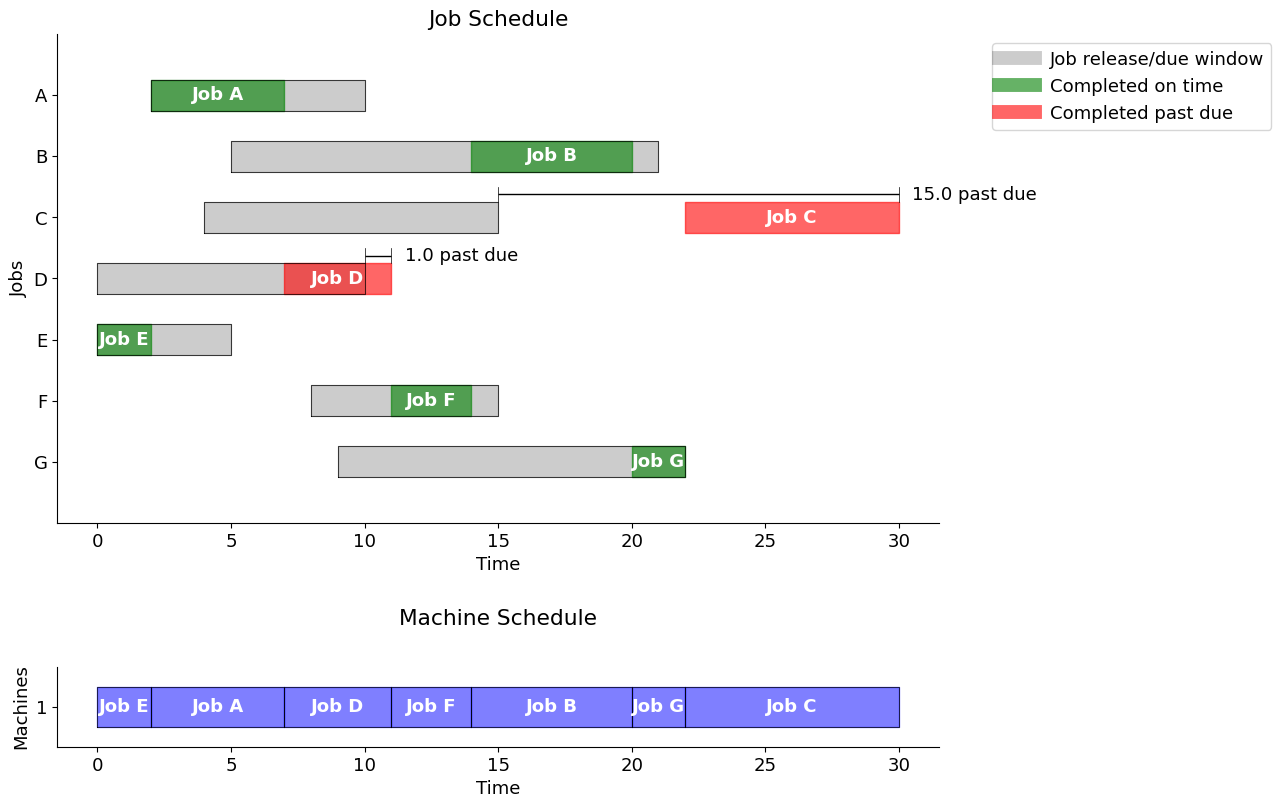

In [18]:
def machine_schedule(jobs):
    m = pyo.ConcreteModel("Job machine scheduling")

    # Create a set of jobs using the dataframe index and a
    # set of orderd pairs of distinct jobs (i,j) with i < j
    m.JOBS = pyo.Set(initialize=jobs.index)
    m.PAIRS = pyo.Set(initialize=m.JOBS * m.JOBS, filter=lambda m, i, j: i < j)

    # We set an upper bound on the time horizon to 100
    m.maxtime = pyo.Param(initialize=100)
    m.start   = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.finish  = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.past    = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))

    @m.Constraint(m.JOBS)
    def job_release(m, job):
        return m.start[job] >= jobs.loc[job, "release"]

    @m.Constraint(m.JOBS)
    def job_duration(m, job):
        return m.finish[job] == m.start[job] + jobs.loc[job, "duration"]

    @m.Constraint(m.JOBS)
    def past_due_constraint(m, job):
        return m.past[job] >= m.finish[job] - jobs.loc[job, "due"]

    @m.Disjunction(m.PAIRS, xor=True)
    def machine_deconflict(m, job_a, job_b):
        return [m.finish[job_a] <= m.start[job_b], m.finish[job_b] <= m.start[job_a]]

    @m.Objective(sense=pyo.minimize)
    def minimize_past(m):
        return sum(m.past[job] for job in m.JOBS)

    return m


m = machine_schedule(jobs)
pyo.TransformationFactory("gdp.bigm").apply_to(m)
SOLVER.solve(m)

optimalschedule = pd.DataFrame(
    {
        "start": m.start.extract_values(),
        "finish": m.finish.extract_values(),
        "past": m.past.extract_values(),
    }
)

display(optimalschedule)
gantt(jobs, optimalschedule, "Minimize total past due")

In [19]:
# print sorted schedule
sorted_optimalschedule = optimalschedule.sort_values(by='start')
display(sorted_optimalschedule)

,start,finish,past
E,0.0,2.0,-0.0
A,2.0,7.0,-0.0
D,7.0,11.0,1.0
F,11.0,14.0,0.0
B,14.0,20.0,-0.0
G,20.0,22.0,-0.0
C,22.0,30.0,15.0


### Conclusion: Empirical vs 0ptimal

The solution obtained solving the optimization problem, TPD = 16, outperforms that derived from any of the empirical rules used above, of which the best was EDD with TPD = 27. Nonetheless, heuristic techniques become essential when addressing very large scheduling problems.

## Optimal Scheduling: Big-M method

For comparison, we could also implement a standard MILP using the big-M method. For this, we introduce a binary variable $z_{ij} \in \{0,1\}$ for each disjunctive constraint above.

$$
\begin{align*}
\text{finish}_i & \leq  \text{start}_j + M z_{ij} \\
\text{finish}_j & \leq  \text{start}_i + M (1 - z_{ij}).
\end{align*}
$$

This creates an equivalent MILP model that leads to the same solution as obtained above by the disjunctive approach, but it introduces many more variables and is usually slower to solve when the problem size is large.

Here, we take a step-by-step approach to the construction of the "Big-M" model.

### Step 1. An incomplete bare-bones model

We start this model building exercise with just enough variables and constraints to get an answer. This is not a complete model and will therefore give non-physical answers. But it does give a scaffold for further model building.

This first model includes: 

- decision variables for the start and finish of each job,
- a decision variable for makespan,
- and constraints that define the relationships among these decision variables.

The objective function is to minimize the makespan.

,start,finish
A,0.0,5.0
B,0.0,6.0
C,0.0,8.0
D,0.0,4.0
E,0.0,2.0
F,0.0,3.0
G,0.0,2.0



 KPI for Bare-Bones Model 

                    0
Makespan          8.0
Max Pastdue       0.0
Sum of Pastdue    0.0
Number Pastdue    0.0
Number on Time    7.0
Fraction on Time  1.0 



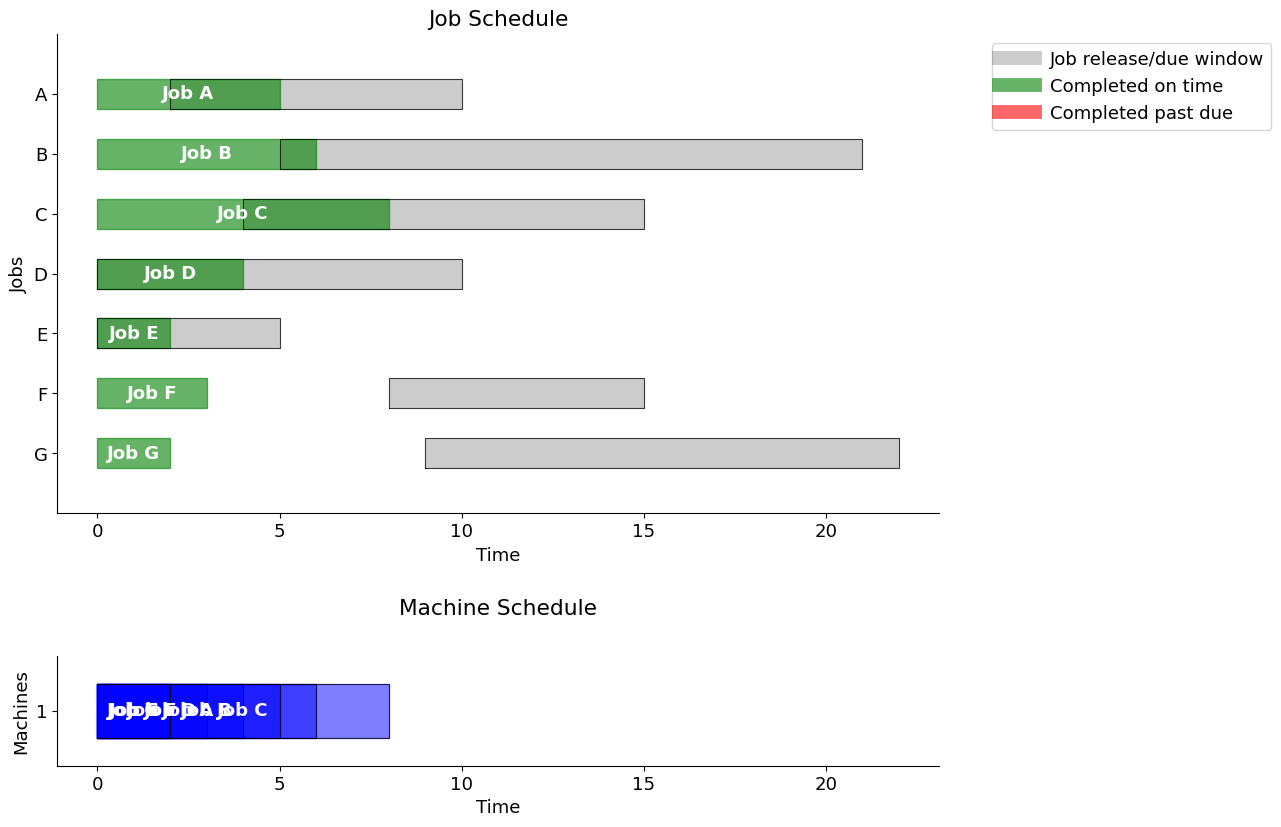

In [20]:
def opt_schedule(JOBS):
    # quick-fix 
    #JOBS = JOBS.T.to_dict()

    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.JOBS = pyo.Set(initialize=JOBS.keys())

    # decision variables
    m.start  = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    
    # additional decision variables for use in the objecive
    m.makespan = pyo.Var(domain=pyo.NonNegativeReals)
    
    # objective function
    m.OBJ = pyo.Objective(expr = m.makespan, sense = pyo.minimize)
    
    # constraints
    m.c = pyo.ConstraintList()
    for j in m.JOBS:
        m.c.add(m.finish[j] == m.start[j] + JOBS[j]['duration'])
        m.c.add(m.finish[j] <= m.makespan)

    pyo.SolverFactory('cbc').solve(m)
    
    SCHEDULE = {}
    for j in m.JOBS:
        SCHEDULE[j] = {'machine': 1, 'start': m.start[j](), 'finish': m.start[j]() + JOBS[j]['duration']}
        
    return m #SCHEDULE

m =  opt_schedule(jobs.T.to_dict())
optimalschedule = pd.DataFrame(
    {
        "start": m.start.extract_values(),
        "finish": m.finish.extract_values(),
#        "past": m.past.extract_values(),
    }
)

display(optimalschedule)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optimalschedule.T.to_dict())
print("\n KPI for Bare-Bones Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optimalschedule, "Bare-Bones Model", pastdue='FALSE')

### Step 2.  Add release time information

Obviously some jobs are being started before they are released for processing. The next version of the model adds this constraint.

,start,finish
A,2.0,7.0
B,5.0,11.0
C,4.0,12.0
D,0.0,4.0
E,0.0,2.0
F,8.0,11.0
G,9.0,11.0



 KPI for Bare-Bones Model 

                     0
Makespan          12.0
Max Pastdue        0.0
Sum of Pastdue     0.0
Number Pastdue     0.0
Number on Time     7.0
Fraction on Time   1.0 



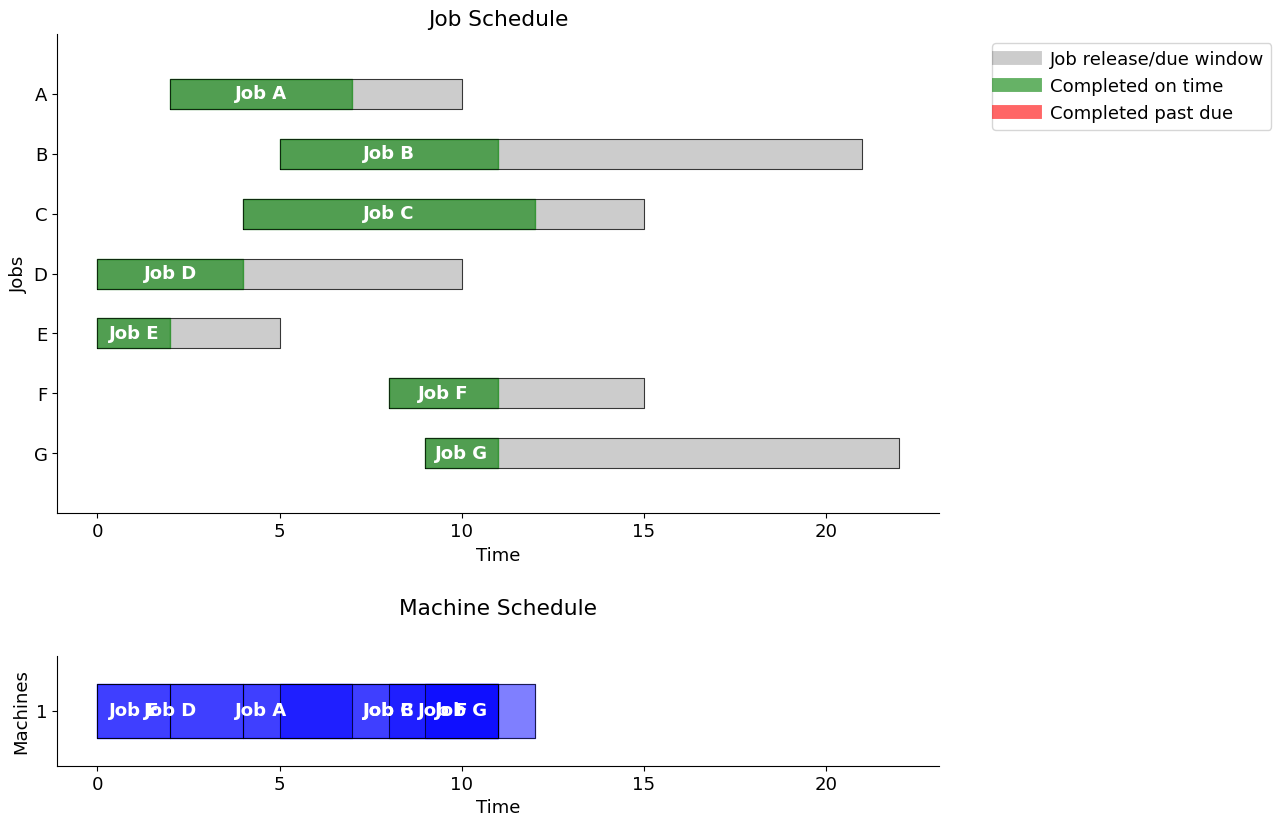

In [21]:
def opt_schedule(JOBS):

    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.JOBS = pyo.Set(initialize=JOBS.keys())

    # decision variables
    m.start = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    
    # additional decision variables for use in the objecive
    m.makespan   = pyo.Var(domain=pyo.NonNegativeReals)
    
    # objective function
    m.OBJ = pyo.Objective(expr = m.makespan, sense = pyo.minimize)
    
    # constraints
    m.c = pyo.ConstraintList()
    for j in m.JOBS:
        m.c.add(m.finish[j] == m.start[j] + JOBS[j]['duration'])
        m.c.add(m.finish[j] <= m.makespan)
        m.c.add(m.start[j] >= JOBS[j]['release']) # release constraint

    pyo.SolverFactory('cbc').solve(m)
    
    SCHEDULE = {}
    for j in m.JOBS:
        SCHEDULE[j] = {'machine': 1, 'start': m.start[j](), 'finish': m.start[j]() + JOBS[j]['duration']}
        
    return m #SCHEDULE

m =  opt_schedule(jobs.T.to_dict())
optimalschedule = pd.DataFrame(
    {
        "start":  m.start.extract_values(),
        "finish": m.finish.extract_values(),
#        "past": m.past.extract_values(),
    }
)

display(optimalschedule)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optimalschedule.T.to_dict())
print("\n KPI for Bare-Bones Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optimalschedule, "Release Constraint Model", pastdue='FALSE')

#SCHEDULE = opt_schedule(JOBS)
#gantt(JOBS, SCHEDULE)
#kpi(JOBS, SCHEDULE)

### Step 3. Machine conflict constraints

The remaining problem is the overlap of the jobs on the machine, which can only execute one job at a time. To remedy this, we must add a conflict constraint.

The big-M formulation expresses the conflict constraint by forcing the jobs to have no overlap, i.e. the next job in the schedule cannot start before its predecessor has finished.

,start,finish
A,2.0,7.0
B,11.0,17.0
C,17.0,25.0
D,7.0,11.0
E,0.0,2.0
F,27.0,30.0
G,25.0,27.0



 KPIs for Big-M Model 

                          0
Makespan          30.000000
Max Pastdue       15.000000
Sum of Pastdue    31.000000
Number Pastdue     4.000000
Number on Time     3.000000
Fraction on Time   0.428571 



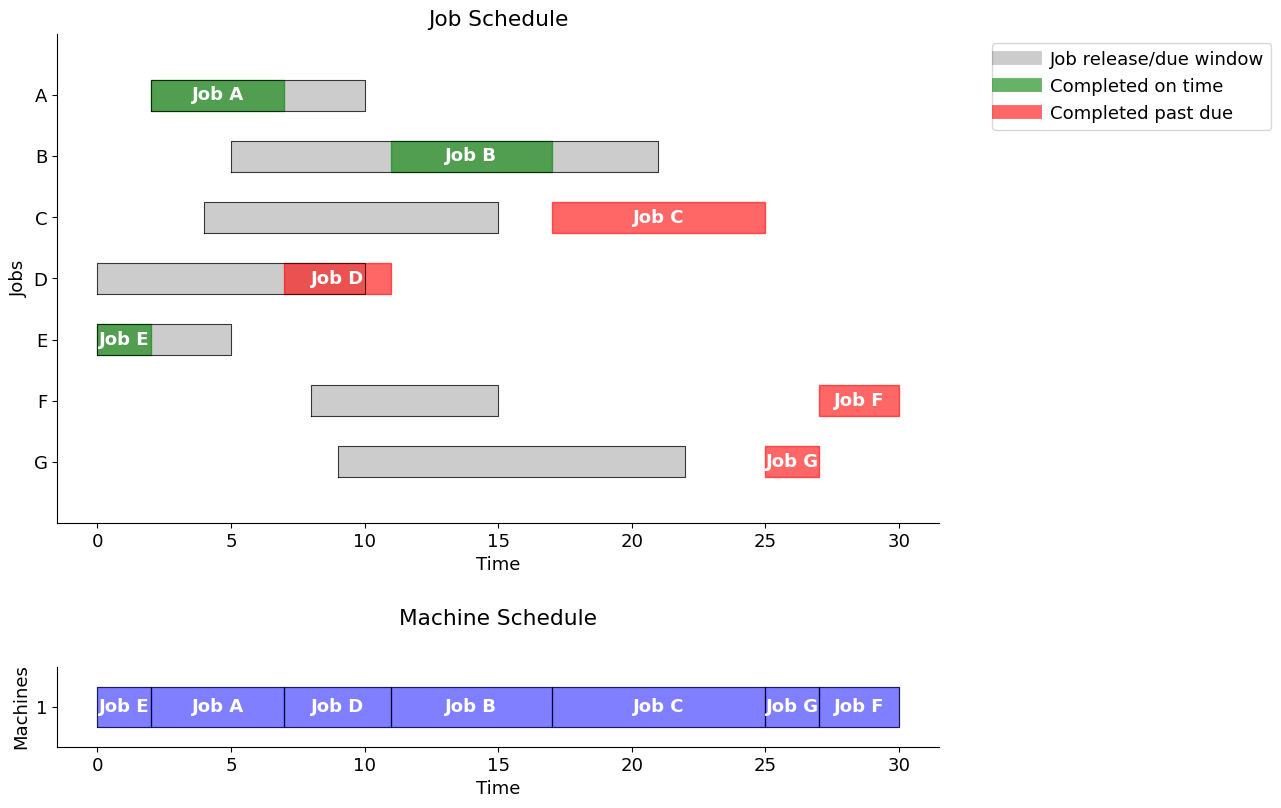

In [22]:
def opt_schedule(JOBS):

    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.JOBS = pyo.Set(initialize=JOBS.keys())
    m.PAIRS = pyo.Set(initialize = m.JOBS * m.JOBS, dimen=2, filter=lambda m, j, k : j < k)

    # decision variables
    m.start = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.y = pyo.Var(m.PAIRS, domain=pyo.Binary)
    
    # additional decision variables for use in the objecive
    m.makespan   = pyo.Var(domain=pyo.NonNegativeReals)
    
    # objective function
    m.OBJ = pyo.Objective(expr = m.makespan, sense = pyo.minimize)
    
    # constraints
    m.c = pyo.ConstraintList()
    for j in m.JOBS:
        m.c.add(m.finish[j] == m.start[j] + JOBS[j]['duration'])
        m.c.add(m.finish[j] <= m.makespan)
        m.c.add(m.start[j] >= JOBS[j]['release'])
    
    M = 100.0
    for j,k in m.PAIRS:
        m.c.add(m.finish[j] <= m.start[k] + M*m.y[j,k])
        m.c.add(m.finish[k] <= m.start[j] + M*(1 - m.y[j,k]))

    pyo.SolverFactory('cbc').solve(m)
    
    SCHEDULE = {}
    for j in m.JOBS:
        SCHEDULE[j] = {'machine': 1, 'start': m.start[j](), 'finish': m.start[j]() + JOBS[j]['duration']}
        
    return m #SCHEDULE

m =  opt_schedule(jobs.T.to_dict())
optimalschedule = pd.DataFrame(
    {
        "start":  m.start.extract_values(),
        "finish": m.finish.extract_values(),
#        "past": m.past.extract_values(),
    }
)

display(optimalschedule)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optimalschedule.T.to_dict())
print("\n KPIs for Big-M Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optimalschedule, "Big-M Model", pastdue='FALSE')

### Step 4. Improved objective function: past due

Until now, we have used a makespan objective. A better objective is the sum of past dues, as was implemented above in the empirical examples.

,start,finish,past
A,2.0,7.0,0.0
B,14.0,20.0,0.0
C,22.0,30.0,15.0
D,7.0,11.0,1.0
E,0.0,2.0,0.0
F,11.0,14.0,0.0
G,20.0,22.0,0.0



 KPIs for Big-M Past Due Model 

                          0
Makespan          30.000000
Max Pastdue       15.000000
Sum of Pastdue    16.000000
Number Pastdue     2.000000
Number on Time     5.000000
Fraction on Time   0.714286 


Using the "Big-M Past Due Model" strategy, the total past due is 16.0



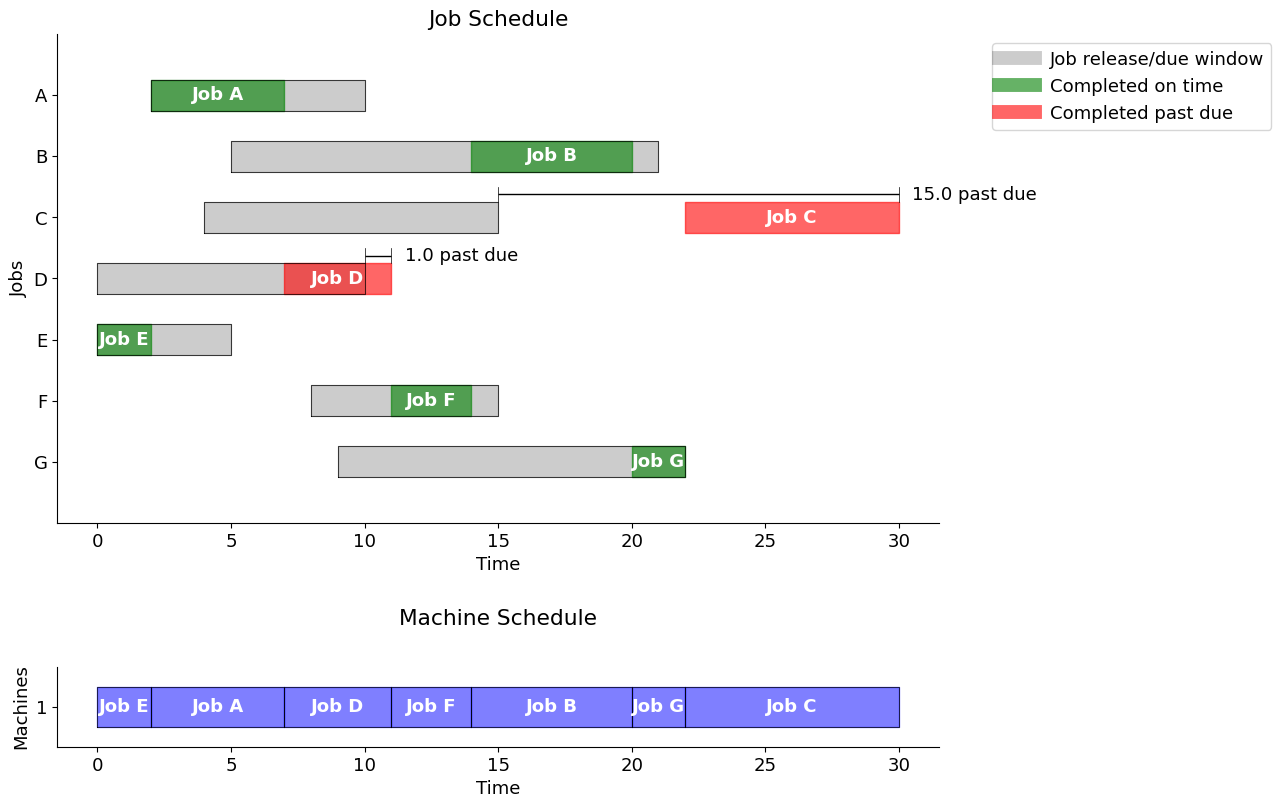

In [23]:
def opt_schedule(JOBS):

    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.JOBS  = pyo.Set(initialize=JOBS.keys())
    m.PAIRS = pyo.Set(initialize = m.JOBS * m.JOBS, dimen=2, filter=lambda m, j, k : j < k)

    # decision variables
    m.start  = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.past   = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals)
    m.y = pyo.Var(m.PAIRS, domain=pyo.Binary)
    
    # additional decision variables for use in the objecive
    m.makespan   = pyo.Var(domain=pyo.NonNegativeReals)
    
    # objective function
    m.OBJ = pyo.Objective(expr = sum(m.past[j] for j in m.JOBS), sense = pyo.minimize)
    
    # constraints
    m.c = pyo.ConstraintList()
    for j in m.JOBS:
        m.c.add(m.finish[j] == m.start[j] + JOBS[j]['duration'])
        m.c.add(m.finish[j] <= m.makespan)
        m.c.add(m.start[j] >= JOBS[j]['release'])
        m.c.add(m.finish[j] <= JOBS[j]['due'] + m.past[j])
    
    M = 100.0
    for j,k in m.PAIRS:
        m.c.add(m.finish[j] <= m.start[k] + M*m.y[j,k])
        m.c.add(m.finish[k] <= m.start[j] + M*(1 - m.y[j,k]))

    pyo.SolverFactory('cbc').solve(m)
    
    SCHEDULE = {}
    for j in m.JOBS:
        SCHEDULE[j] = {'machine': 1, 'start': m.start[j](), 'finish': m.start[j]() + JOBS[j]['duration']}
        
    return m #SCHEDULE

# Solve and print
m =  opt_schedule(jobs.T.to_dict())
optimalschedule = pd.DataFrame(
    {
        "start":  m.start.extract_values(),
        "finish": m.finish.extract_values(),
        "past": m.past.extract_values(),
    }
)

display(optimalschedule)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optimalschedule.T.to_dict())
print("\n KPIs for Big-M Past Due Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optimalschedule, "Big-M Past Due Model", pastdue='TRUE')

**Observations**

We notice the improvement here.

1. The total lateness has decreased from 31 to 16.
2. The number of late jobs is only 2, compared to 4 previously. 

## Multiple Machines: Big-M Formulation

The case of multiple machines requires a modest extension of model described above. Given a set $M$ of machines, we introduce an additional decision binary variable $z_{j,m}$ indicating if job $j$ has been assigned to machine $m$. The additional constraints

$$
\begin{align*}
\sum_{m\in M}z_{j,m} & = 1 & \forall j
\end{align*}
$$

require each job to be assigned to exactly one machine for processing.  

If both jobs $j$ and $k$ have been assigned to machine $m$, then the disjunctive ordering constraints must apply.  This logic is equivalent to the following constraints for $j < k$.

$$
\begin{align*}
\text{start}_{j}+\text{duration}_{j} & \leq \text{start}_{k}+My_{j,k} + M(1-z_{j,m}) + M(1-z_{k,m})\\
\text{start}_{k}+\text{duration}_{k} & \leq \text{start}_{j}+M(1-y_{j,k}) + M(1-z_{j,m}) + M(1-z_{k,m}))
\end{align*}
$$

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: -15.0
  Upper bound: -15.0
  Number of objectives: 1
  Number of constraints: 98
  Number of variables: 50
  Number of binary variables: 42
  Number of integer variables: 42
  Number of nonzeros: 15
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.25
  Wallclock time: 0.28
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound

,start,finish,machine
job,,,
A,2.0,7.0,B
B,7.0,13.0,B
C,4.0,12.0,A
D,0.0,4.0,A
E,0.0,2.0,B
F,12.0,15.0,A
G,13.0,15.0,B



 KPIs for Big-M Multiple Machine Model 

                     0
Makespan          15.0
Max Pastdue        0.0
Sum of Pastdue     0.0
Number Pastdue     0.0
Number on Time     7.0
Fraction on Time   1.0 



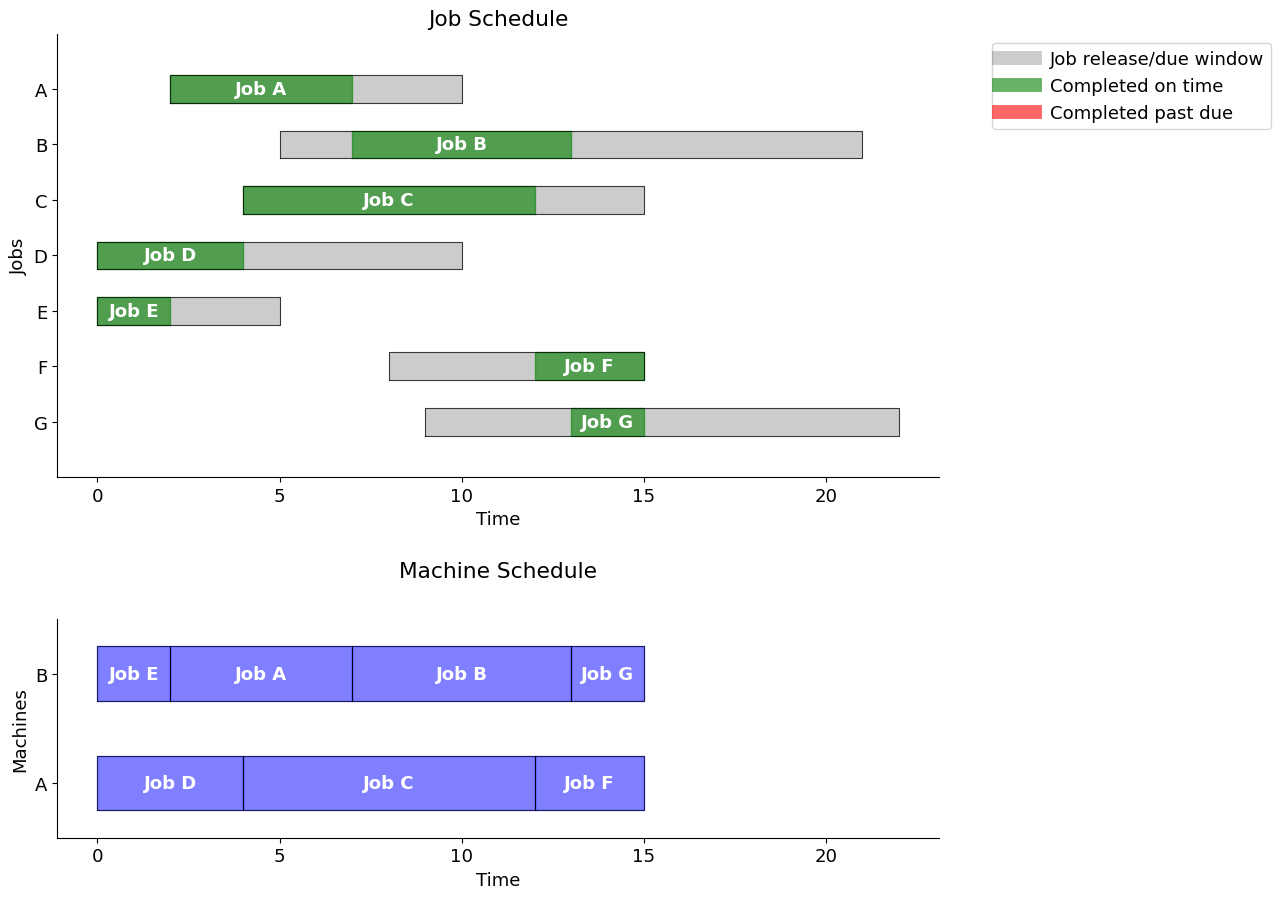

In [24]:
MACHINES = ['A','B']

def schedule_machines(JOBS, MACHINES):
    
    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.J = pyo.Set(initialize=JOBS.keys())
    m.M = pyo.Set(initialize=MACHINES)
    m.PAIRS = pyo.Set(initialize = m.J * m.J, dimen=2, filter=lambda m, j, k : j < k)

    # decision variables
    m.start      = pyo.Var(m.J, bounds=(0, 1000))
    m.makespan   = pyo.Var(domain=pyo.NonNegativeReals)
    m.past       = pyo.Var(m.J, domain=pyo.NonNegativeReals)
    m.early      = pyo.Var(m.J, domain=pyo.NonNegativeReals)
    
    # additional decision variables for use in the objecive
    m.ispastdue  = pyo.Var(m.J, domain=pyo.Binary)
    m.maxpastdue = pyo.Var(domain=pyo.NonNegativeReals)
    
    # for binary assignment of jobs to machines
    m.z = pyo.Var(m.J, m.M, domain=pyo.Binary)

    # for modeling disjunctive constraints
    m.y = pyo.Var(m.PAIRS, domain=pyo.Binary)
    BigM = max([JOBS[j]['release'] for j in m.J]) + sum([JOBS[j]['duration'] for j in m.J])

    m.OBJ = pyo.Objective(expr = sum(m.past[j] for j in m.J) + m.makespan - sum(m.early[j] for j in m.J), sense = pyo.minimize)

    m.c1 = pyo.Constraint(m.J, rule=lambda m, j: 
            m.start[j] >= JOBS[j]['release'])
    m.c2 = pyo.Constraint(m.J, rule=lambda m, j:
            m.start[j] + JOBS[j]['duration'] + m.early[j] == JOBS[j]['due'] + m.past[j])
    m.c3 = pyo.Constraint(m.J, rule=lambda m, j: 
            sum(m.z[j,mach] for mach in m.M) == 1)
    m.c4 = pyo.Constraint(m.J, rule=lambda m, j: 
            m.past[j] <= BigM*m.ispastdue[j])
    m.c5 = pyo.Constraint(m.J, rule=lambda m, j: 
            m.past[j] <= m.maxpastdue)
    m.c6 = pyo.Constraint(m.J, rule=lambda m, j: 
            m.start[j] + JOBS[j]['duration'] <= m.makespan)
    m.d1 = pyo.Constraint(m.M, m.PAIRS, rule = lambda m, mach, j, k:
            m.start[j] + JOBS[j]['duration'] <= m.start[k] + BigM*(m.y[j,k] + (1-m.z[j,mach]) + (1-m.z[k,mach])))
    m.d2 = pyo.Constraint(m.M, m.PAIRS, rule = lambda m, mach, j, k: 
            m.start[k] + JOBS[k]['duration'] <= m.start[j] + BigM*((1-m.y[j,k]) + (1-m.z[j,mach]) + (1-m.z[k,mach])))
 
    pyo.SolverFactory('cbc').solve(m).write()
    
    SCHEDULE = {}
    for j in m.J:
        SCHEDULE[j] = {
            'start': m.start[j](), 
            'finish': m.start[j]() + JOBS[j]['duration'],
            'machine': [mach for mach in MACHINES if m.z[j,mach]()][0]
        }
        
    return m, SCHEDULE

# Solve and print
m, SCHED =  schedule_machines(jobs.T.to_dict(), MACHINES)
# Restructure into column-oriented dict
SCD = {
    'start':   {job: data['start']   for job, data in SCHED.items()},
    'finish':  {job: data['finish']  for job, data in SCHED.items()},
    'machine': {job: data['machine'] for job, data in SCHED.items()},
}
# Convert to DataFrame (job names become the index)
optsched = pd.DataFrame(SCD)
optsched.index.name = 'job'
display(optsched)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optsched.T.to_dict())
print("\n KPIs for Big-M Multiple Machine Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optsched, "Big-M Multiple Machine Model", pastdue='FALSE')

## Multiple Machines:  Disjunctive Formulation

We solve the same multi-machine problem using Pyomo's disjunctive capabilities. The results obtained are identical, but the CPUI times are different - see Observations below.

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: -15.0
  Upper bound: -15.0
  Number of objectives: 1
  Number of constraints: 637
  Number of variables: 435
  Number of binary variables: 133
  Number of integer variables: 133
  Number of nonzeros: 15
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 1.07
  Wallclock time: 1.12
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and b

,start,finish,machine
job,,,
A,2.0,7.0,A
B,7.0,13.0,A
C,4.0,12.0,B
D,0.0,4.0,B
E,0.0,2.0,A
F,12.0,15.0,B
G,13.0,15.0,A



 KPIs for Disjunctive Multiple Machine Model 

                     0
Makespan          15.0
Max Pastdue        0.0
Sum of Pastdue     0.0
Number Pastdue     0.0
Number on Time     7.0
Fraction on Time   1.0 



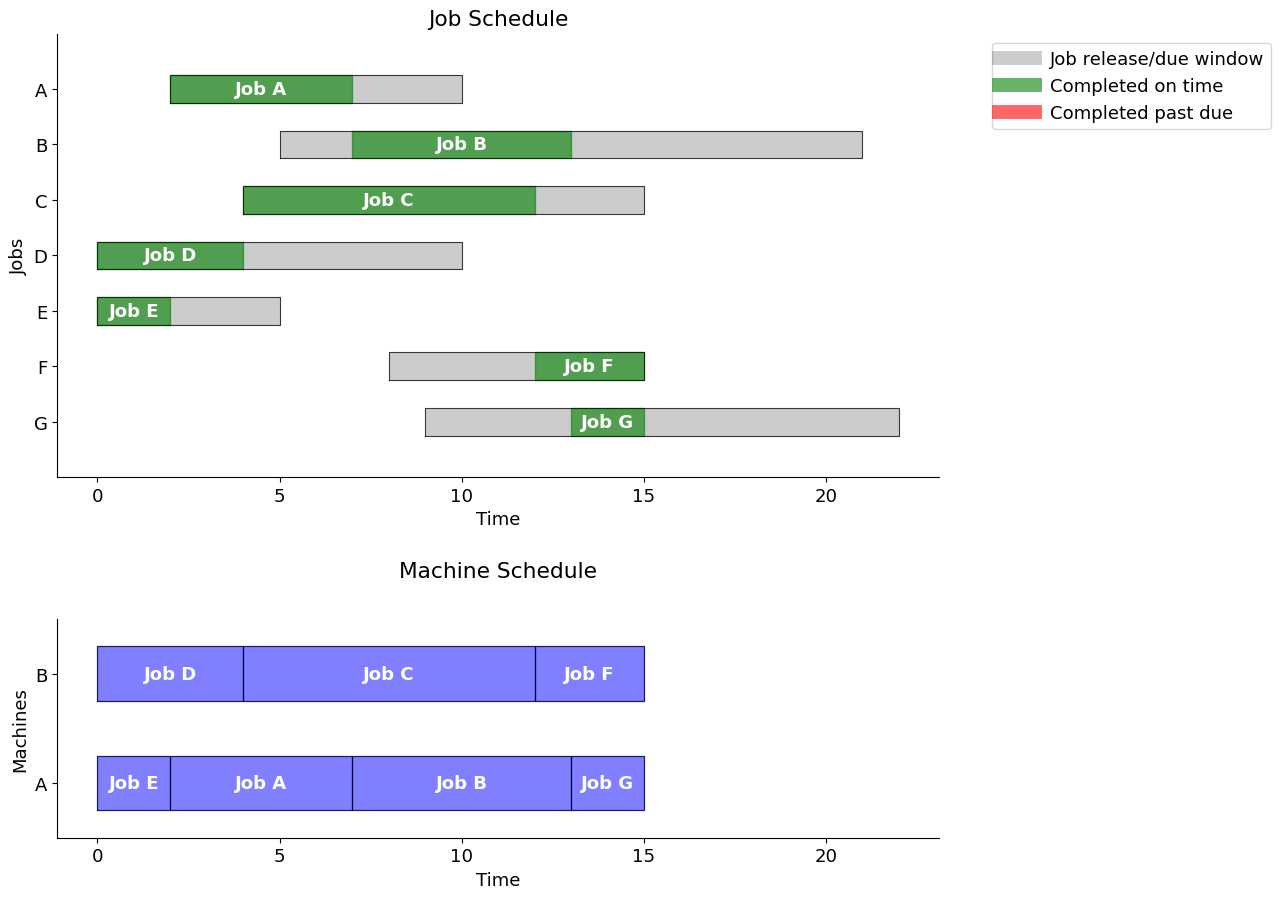

In [25]:
from pyomo.gdp import Disjunct, Disjunction

MACHINES = ['A','B']

def schedule_machines(JOBS, MACHINES):
    
    # create model
    m = pyo.ConcreteModel()
    
    # index set to simplify notation
    m.J = pyo.Set(initialize=JOBS.keys())
    m.M = pyo.Set(initialize=MACHINES)
    m.PAIRS = pyo.Set(initialize = m.J * m.J, dimen=2, filter=lambda m, j, k : j < k)

    # decision variables
    m.start      = pyo.Var(m.J, bounds=(0, 1000))
    m.makespan   = pyo.Var(domain=pyo.NonNegativeReals)
    m.pastdue    = pyo.Var(m.J, bounds=(0, 1000))
    m.early      = pyo.Var(m.J, bounds=(0, 10000))
    
    # additional decision variables for use in the objecive
    m.ispastdue  = pyo.Var(m.J, domain=pyo.Binary)
    m.maxpastdue = pyo.Var(domain=pyo.NonNegativeReals)
    
    # for binary assignment of jobs to machines
    m.z = pyo.Var(m.J, m.M, domain=pyo.Binary)

    # for modeling disjunctive constraints
    BigM = max([JOBS[j]['release'] for j in m.J]) + sum([JOBS[j]['duration'] for j in m.J])

    m.OBJ = pyo.Objective(expr = sum(m.pastdue[j] for j in m.J) + m.makespan - sum(m.early[j] for j in m.J), sense = pyo.minimize)

    # job starts after it is released
    m.c1 = pyo.Constraint(m.J, rule=lambda m, j: m.start[j] >= JOBS[j]['release'])

    # defines early and pastdue
    m.c2 = pyo.Constraint(m.J, rule=lambda m, j: m.start[j] + JOBS[j]['duration'] + m.early[j] == JOBS[j]['due'] + m.pastdue[j])
    m.d1 = Disjunction(m.J, rule=lambda m, j: [m.early[j]==0, m.pastdue[j]==0])

    # each job is assigned to one and only one machine
    m.c3 = pyo.Constraint(m.J, rule=lambda m, j: sum(m.z[j, mach] for mach in m.M) == 1)

    # defines a binary variable indicating if a job is past due
    m.c4 = Disjunction(m.J, rule=lambda m, j: [m.pastdue[j] == 0, m.ispastdue[j] == 1])

    # all jobs must be finished before max pastdue
    m.c5 = pyo.Constraint(m.J, rule=lambda m, j: m.pastdue[j] <= m.maxpastdue)

    # defining make span
    m.c6 = pyo.Constraint(m.J, rule=lambda m, j: m.start[j] + JOBS[j]['duration'] <= m.makespan)
 
    # disjuctions
    m.d0 = Disjunction(m.M, m.PAIRS, rule = lambda m, mach, j, k: 
                       [m.start[j] + JOBS[j]['duration'] <= m.start[k] + BigM*((1-m.z[j, mach]) + (1-m.z[k, mach])),
                        m.start[k] + JOBS[k]['duration'] <= m.start[j] + BigM*((1-m.z[j, mach]) + (1-m.z[k, mach]))])
  
    transform = pyo.TransformationFactory('gdp.hull')
    transform.apply_to(m)

    pyo.SolverFactory('cbc').solve(m).write()
    
    SCHEDULE = {}
    for j in m.J:
        SCHEDULE[j] = {
            'start': m.start[j](), 
            'finish': m.start[j]() + JOBS[j]['duration'],
            'machine': [mach for mach in MACHINES if m.z[j,mach]()][0]
        }
        
    return m, SCHEDULE

# Solve and print
m, SCHED =  schedule_machines(jobs.T.to_dict(), MACHINES)
# Restructure into column-oriented dict
SCD = {
    'start':   {job: data['start']   for job, data in SCHED.items()},
    'finish':  {job: data['finish']  for job, data in SCHED.items()},
    'machine': {job: data['machine'] for job, data in SCHED.items()},
}
# Convert to DataFrame (job names become the index)
optsched = pd.DataFrame(SCD)
optsched.index.name = 'job'
display(optsched)
# print KPI's
KPI_out = kpi(jobs.T.to_dict(),  optsched.T.to_dict())
print("\n KPIs for Disjunctive Multiple Machine Model \n")
print(pd.DataFrame.from_dict(KPI_out, orient='index'),"\n")
# output graphics for schedule by job, by machine
gantt(jobs, optsched, "Disjunctive Multiple Machine Model", pastdue='FALSE')

#SCHEDULE = schedule_machines(JOBS,MACHINES)
#gantt(JOBS, SCHEDULE)
#kpi(JOBS, SCHEDULE)

**OBSERVATIONS**

1. The results are identical with those obtained previously using the Big-M approach.
2. The CPU time is 1.12 vs 0.28 for the Big-M, a factor of 4X. Even though, in principle, Big-M introduces more variables and takes more time, this is not the case here due to the relatively small problem size.